In [22]:
"""
Comprehensive EDA: Grocery Product Catalog
==========================================
Senior Data Analyst Report — Revised
"""

'\nComprehensive EDA: Grocery Product Catalog\n==========================================\nSenior Data Analyst Report — Revised\n'

# Comprehensive EDA — Grocery Product Catalog

**Analyst Note:** This dataset is a product catalog scraped from an online grocery retailer
(likely Costco). It contains product listings with prices, ratings, discount status, and text
descriptions. **It is not a transactional/sales dataset** — there are no quantities sold, dates,
or customer IDs. The unit of analysis is a *product listing*, not a purchase.

**Unit of analysis:** Each row represents one product–category assignment.
A single product title may appear in multiple categories (cross-listing).
This report distinguishes between *rows* (1,754) and *unique product titles* (1,484)
throughout, and flags where cross-listing affects conclusions.

**Structure:**
1. Data Inspection & Cleaning
2. Univariate Analysis
3. Cross-Category & Normalized Analysis
4. Text Mining & Brand Analysis
5. Product Opportunity Analysis
6. Key Findings & Recommendations

In [23]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 140,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans',
})

BLUE = '#2563EB'
AMBER = '#F59E0B'
GREEN = '#10B981'
RED = '#EF4444'
PURPLE = '#8B5CF6'
GRAY = '#94A3B8'
PALETTE = [BLUE, AMBER, GREEN, RED, PURPLE, '#EC4899', '#06B6D4', '#F97316']

df_raw = pd.read_csv("GroceryDataset.csv")
print(f"Raw dataset: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

Raw dataset: 1757 rows × 8 columns


---
## 1 · Data Inspection & Cleaning

### 1.1 — Raw Structure & Missingness

In [24]:
print("COLUMNS & DATA TYPES")
print("-" * 60)
for c in df_raw.columns:
    n_miss = df_raw[c].isna().sum()
    pct = n_miss / len(df_raw) * 100
    n_uniq = df_raw[c].nunique()
    print(f"  {c:30s}  dtype={str(df_raw[c].dtype):6s}  "
          f"missing={n_miss:5d} ({pct:5.1f}%)  unique={n_uniq}")

print(f"\nExact duplicate rows: {df_raw.duplicated().sum()}")

COLUMNS & DATA TYPES
------------------------------------------------------------
  Sub Category                    dtype=object  missing=    0 (  0.0%)  unique=19
  Price                           dtype=object  missing=    3 (  0.2%)  unique=184
  Discount                        dtype=object  missing=    0 (  0.0%)  unique=42
  Rating                          dtype=object  missing= 1075 ( 61.2%)  unique=483
  Title                           dtype=object  missing=    0 (  0.0%)  unique=1484
  Currency                        dtype=object  missing=    5 (  0.3%)  unique=1
  Feature                         dtype=object  missing=   18 (  1.0%)  unique=1401
  Product Description             dtype=object  missing=   42 (  2.4%)  unique=1435

Exact duplicate rows: 3


**Observations:**
- All columns are stored as strings — `Price`, `Rating`, and `Discount` require parsing.
- `Rating` is missing for **61.2%** of rows. This is the dominant data-quality issue.
- `Price` and `Currency` have negligible missingness (3 and 5 rows).
- 3 exact duplicate rows will be dropped.
- `Feature` and `Product Description` are free-text fields with minor gaps.

In [25]:
def parse_price(val):
    """Extract numeric price from strings like '$56.99 '."""
    if pd.isna(val):
        return np.nan
    m = re.search(r'[\d,.]+', str(val).replace(',', ''))
    return float(m.group()) if m else np.nan

def parse_rating(val):
    """Extract rating and review count from strings like
    'Rated 4.3 out of 5 stars based on 265 reviews.'"""
    if pd.isna(val):
        return np.nan, np.nan
    m_r = re.search(r'Rated\s+([\d.]+)', str(val))
    m_n = re.search(r'based on\s+([\d,]+)', str(val))
    rating = float(m_r.group(1)) if m_r else np.nan
    reviews = int(m_n.group(1).replace(',', '')) if m_n else np.nan
    return rating, reviews

def parse_discount(val):
    """Extract discount dollar amount from strings like 'After $5 OFF'."""
    if pd.isna(val):
        return 0.0
    m = re.search(r'\$([\d,.]+)', str(val))
    return float(m.group(1).replace(',', '')) if m else 0.0

df = df_raw.copy()
df['price'] = df['Price'].apply(parse_price)
df[['rating', 'review_count']] = df['Rating'].apply(
    lambda x: pd.Series(parse_rating(x))
)
df['discount_amt'] = df['Discount'].apply(parse_discount)
df['has_discount'] = df['discount_amt'] > 0
df['discount_pct'] = np.where(
    df['price'] > 0,
    (df['discount_amt'] / df['price'] * 100).round(1),
    0
)
df['category'] = df['Sub Category'].str.strip()

# Drop exact duplicates
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
print(f"Dropped {n_before - n_after} exact duplicates → {n_after} rows remaining")

Dropped 3 exact duplicates → 1754 rows remaining


In [26]:
print("\nParsed field summary:")
print(f"  price:        {df['price'].notna().sum()} valid, "
      f"range ${df['price'].min():.2f} – ${df['price'].max():.2f}")
print(f"  rating:       {df['rating'].notna().sum()} valid ({df['rating'].notna().mean()*100:.1f}%), "
      f"range {df['rating'].min():.1f} – {df['rating'].max():.1f}")
print(f"  review_count: {df['review_count'].notna().sum()} valid, "
      f"range {df['review_count'].min():.0f} – {df['review_count'].max():.0f}")
print(f"  discount_amt: {df['has_discount'].sum()} products discounted ({df['has_discount'].mean()*100:.1f}%), "
      f"range ${df.loc[df['has_discount'],'discount_amt'].min():.2f} – "
      f"${df.loc[df['has_discount'],'discount_amt'].max():.2f}")


Parsed field summary:
  price:        1751 valid, range $3.99 – $1999.99
  rating:       617 valid (35.2%), range 1.0 – 5.0
  review_count: 617 valid, range 1 – 18098
  discount_amt: 123 products discounted (7.0%), range $1.50 – $80.00


### 1.4 — Critical Data-Quality Finding: Cross-Listed Products

Many product titles appear in **multiple categories**. This is not a data error —
it reflects the retailer's multi-category taxonomy (e.g., a Kirkland Signature
item appears under both "Kirkland Signature Grocery" and "Pantry & Dry Goods").
However, this means **raw category counts overstate true assortment breadth**.

In [27]:
title_cat_counts = df.groupby('Title')['category'].nunique()
multi_cat_titles = title_cat_counts[title_cat_counts > 1]
single_cat_titles = title_cat_counts[title_cat_counts == 1]

df['is_crosslisted'] = df['Title'].isin(multi_cat_titles.index)

extra_rows = len(df) - df['Title'].nunique()

print("CROSS-LISTING AUDIT")
print("-" * 60)
print(f"  Total rows:                       {len(df)}")
print(f"  Unique product titles:            {df['Title'].nunique()}")
print(f"  Titles in exactly 1 category:     {len(single_cat_titles)}")
print(f"  Titles in >1 category:            {len(multi_cat_titles)} "
      f"({len(multi_cat_titles)/df['Title'].nunique()*100:.1f}% of unique titles)")
print(f"  Total rows from those {len(multi_cat_titles)} titles: {df['is_crosslisted'].sum()}")
print(f"  Extra rows from cross-listing:    {extra_rows} "
      f"(= {len(df)} rows − {df['Title'].nunique()} unique titles)")
print(f"\n  Arithmetic check: {len(single_cat_titles)} single-cat titles + "
      f"{len(multi_cat_titles)} multi-cat titles = {len(single_cat_titles)+len(multi_cat_titles)} "
      f"unique titles ✓")

print(f"\nSample cross-listed products:")
for t in list(multi_cat_titles.nlargest(5).index)[:5]:
    cats = df[df['Title'] == t]['category'].unique()
    print(f"  • '{t[:60]}…'\n    → {list(cats)}")

CROSS-LISTING AUDIT
------------------------------------------------------------
  Total rows:                       1754
  Unique product titles:            1484
  Titles in exactly 1 category:     1237
  Titles in >1 category:            247 (16.6% of unique titles)
  Total rows from those 247 titles: 515
  Extra rows from cross-listing:    270 (= 1754 rows − 1484 unique titles)

  Arithmetic check: 1237 single-cat titles + 247 multi-cat titles = 1484 unique titles ✓

Sample cross-listed products:
  • 'D'Artagnan 13-piece Gourmet Roasting Ham & Luxury Charcuteri…'
    → ['Deli', 'Gift Baskets', 'Meat & Seafood']
  • 'Kirkland Signature Fabric Softener Sheets, 250-count, 2-pack…'
    → ['Cleaning Supplies', 'Kirkland Signature Grocery', 'Laundry Detergent & Supplies']
  • 'Kirkland Signature Organic Blue Agave, 36 oz, 2-count…'
    → ['Kirkland Signature Grocery', 'Organic', 'Pantry & Dry Goods']
  • 'Kirkland Signature Organic No-Salt Seasoning, 14.5 oz…'
    → ['Kirkland Signature G

In [28]:
print("\nTop category overlap pairs (shared product titles):")
title_cats = df.groupby('Title')['category'].apply(set)
multi = title_cats[title_cats.apply(len) > 1]
pair_counts = Counter()
for cats_set in multi:
    cats = sorted(cats_set)
    for i in range(len(cats)):
        for j in range(i + 1, len(cats)):
            pair_counts[(cats[i], cats[j])] += 1

for (c1, c2), cnt in list(pair_counts.most_common(10)):
    print(f"  {cnt:3d} shared titles: {c1} ↔ {c2}")


Top category overlap pairs (shared product titles):
   47 shared titles: Meat & Seafood ↔ Seafood
   39 shared titles: Cleaning Supplies ↔ Laundry Detergent & Supplies
   28 shared titles: Kirkland Signature Grocery ↔ Pantry & Dry Goods
   25 shared titles: Kirkland Signature Grocery ↔ Snacks
   16 shared titles: Coffee ↔ Kirkland Signature Grocery
   16 shared titles: Kirkland Signature Grocery ↔ Organic
   15 shared titles: Organic ↔ Pantry & Dry Goods
   14 shared titles: Deli ↔ Gift Baskets
   12 shared titles: Kirkland Signature Grocery ↔ Paper & Plastic Products
    9 shared titles: Meat & Seafood ↔ Poultry


**Implication:** The heaviest overlaps are:
- **Meat & Seafood ↔ Seafood** (47 shared titles — these are essentially the same category)
- **Cleaning Supplies ↔ Laundry** (39 shared)
- **Kirkland Signature ↔ Pantry/Snacks/Coffee** — Kirkland is a brand tag, not a product category

This means "Kirkland Signature Grocery" inflates its row count by pulling
products that also exist in functional categories. All subsequent category-level
analyses will report both raw counts and unique-title counts.

### 1.5 — Rating Coverage by Category (Critical Diagnostic)

Before comparing ratings across categories, we must understand how much
of each category actually *has* ratings. An average rating computed from
2 products is not comparable to one computed from 130.

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/fig_01_rating_coverage.png'

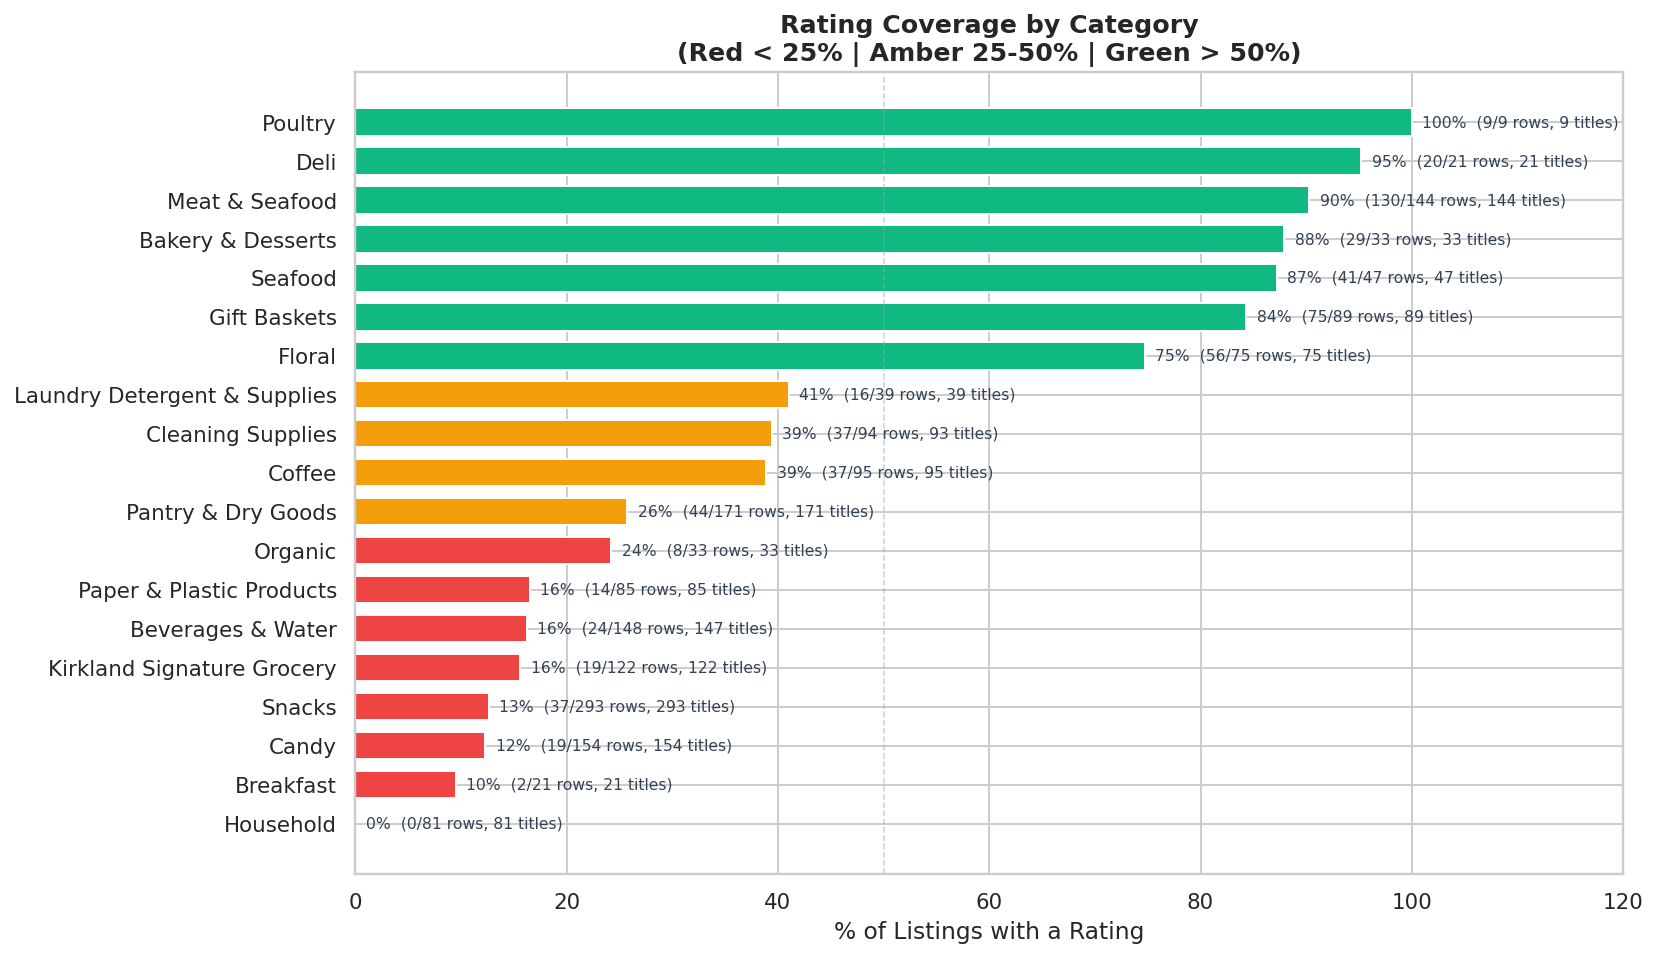

In [29]:
coverage = (df.groupby('category')
            .agg(
                total_rows=('rating', 'size'),
                rated_rows=('rating', 'count'),
                unique_titles=('Title', 'nunique'),
                crosslisted=('is_crosslisted', 'sum')
            )
            .assign(coverage_pct=lambda x: (x.rated_rows / x.total_rows * 100).round(1))
            .sort_values('coverage_pct', ascending=True))

fig, ax = plt.subplots(figsize=(12, 7))
colors = [RED if c < 25 else AMBER if c < 50 else GREEN 
          for c in coverage['coverage_pct']]
bars = ax.barh(coverage.index, coverage['coverage_pct'], color=colors, 
               edgecolor='white', height=0.7)
for bar, (idx, row) in zip(bars, coverage.iterrows()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{row['coverage_pct']:.0f}%  ({int(row['rated_rows'])}/{int(row['total_rows'])} rows, "
            f"{int(row['unique_titles'])} titles)",
            va='center', fontsize=8, color='#334155')
ax.set_xlim(0, 120)
ax.axvline(50, color=GRAY, ls='--', lw=0.8, alpha=0.5)
ax.set_title('Rating Coverage by Category\n(Red < 25% | Amber 25-50% | Green > 50%)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('% of Listings with a Rating')
plt.tight_layout()
plt.savefig('/home/claude/fig_01_rating_coverage.png', bbox_inches='tight')
plt.show()

**Key takeaway:** Rating coverage ranges from **0%** (Household) to **100%** (Poultry).
Seven categories have coverage below 25%. Any rating-based comparison for these
categories must note the tiny sample size. Household products have **zero** ratings,
making satisfaction analysis impossible for that segment.

---
## 2 · Univariate Analysis

### 2.1 — Price Distribution

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/fig_02_price_dist.png'

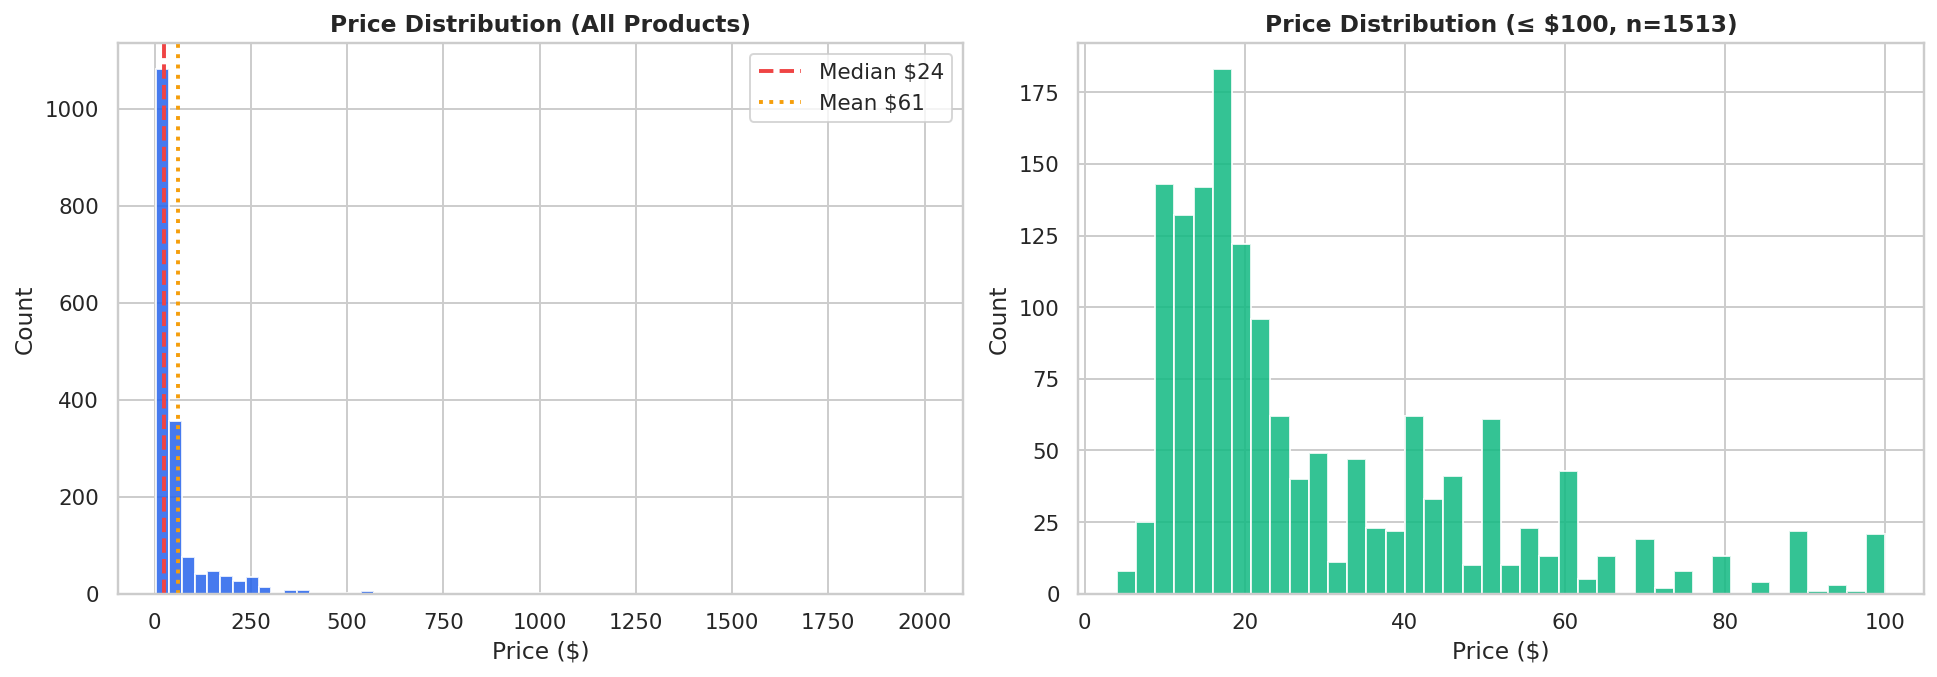

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['price'].dropna(), bins=60, color=BLUE, edgecolor='white', alpha=0.85)
med = df['price'].median()
ax.axvline(med, color=RED, ls='--', lw=2, label=f"Median ${med:.0f}")
ax.axvline(df['price'].mean(), color=AMBER, ls=':', lw=2, label=f"Mean ${df['price'].mean():.0f}")
ax.set_title('Price Distribution (All Products)', fontweight='bold')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Count')
ax.legend()

ax = axes[1]
sub_price = df.loc[df['price'] <= 100, 'price'].dropna()
ax.hist(sub_price, bins=40, color=GREEN, edgecolor='white', alpha=0.85)
ax.set_title(f'Price Distribution (≤ $100, n={len(sub_price)})', fontweight='bold')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('/home/claude/fig_02_price_dist.png', bbox_inches='tight')
plt.show()

print(f"Price statistics:")
print(f"  Median: ${df['price'].median():.2f}")
print(f"  Mean:   ${df['price'].mean():.2f}")
print(f"  Std:    ${df['price'].std():.2f}")
print(f"  Skew:   {df['price'].skew():.2f}")
print(f"  IQR:    ${df['price'].quantile(0.25):.2f} – ${df['price'].quantile(0.75):.2f}")
print(f"  P90:    ${df['price'].quantile(0.90):.2f}")
print(f"  P99:    ${df['price'].quantile(0.99):.2f}")

**Heavily right-skewed** (skewness = 8.3). The median ($24) is far below the mean ($61),
indicating a long tail of premium/specialty items. The IQR is $15–$53, so the
core catalog is mid-priced. Above P90 ($150), products are almost exclusively
from Meat & Seafood and Gift Baskets. **All subsequent price-based summaries
use medians** to avoid distortion by outliers.

In [ ]:
rated = df.dropna(subset=['rating']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(rated['review_count'], bins=60, color=BLUE, edgecolor='white', alpha=0.85)
ax.axvline(rated['review_count'].median(), color=RED, ls='--', lw=2,
           label=f"Median {rated['review_count'].median():.0f}")
ax.set_title(f'Review Count Distribution (n={len(rated)} rated products)',
             fontweight='bold')
ax.set_xlabel('Review Count')
ax.set_ylabel('Count')
ax.legend()

ax = axes[1]
ax.hist(np.log1p(rated['review_count']), bins=40, color=PURPLE, edgecolor='white', alpha=0.85)
ax.set_title('Review Count (log scale)', fontweight='bold')
ax.set_xlabel('log(1 + reviews)')
ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('/home/claude/fig_03_review_dist.png', bbox_inches='tight')
plt.show()

print(f"Review count (rated products only, n={len(rated)}):")
print(f"  Median: {rated['review_count'].median():.0f}")
print(f"  Mean:   {rated['review_count'].mean():.0f}")
print(f"  Skew:   {rated['review_count'].skew():.2f}")
print(f"  P90:    {rated['review_count'].quantile(0.9):.0f}")
print(f"  P99:    {rated['review_count'].quantile(0.99):.0f}")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(rated['rating'], bins=np.arange(0.5, 5.75, 0.25), color=BLUE,
        edgecolor='white', alpha=0.85)
ax.axvline(rated['rating'].mean(), color=RED, ls='--', lw=2,
           label=f"Mean {rated['rating'].mean():.2f}")
ax.set_title(f'Rating Distribution (n={len(rated)} rated products)', fontweight='bold')
ax.set_xlabel('Rating (out of 5)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('/home/claude/fig_04_rating_dist.png', bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/fig_05_category_freq.png'

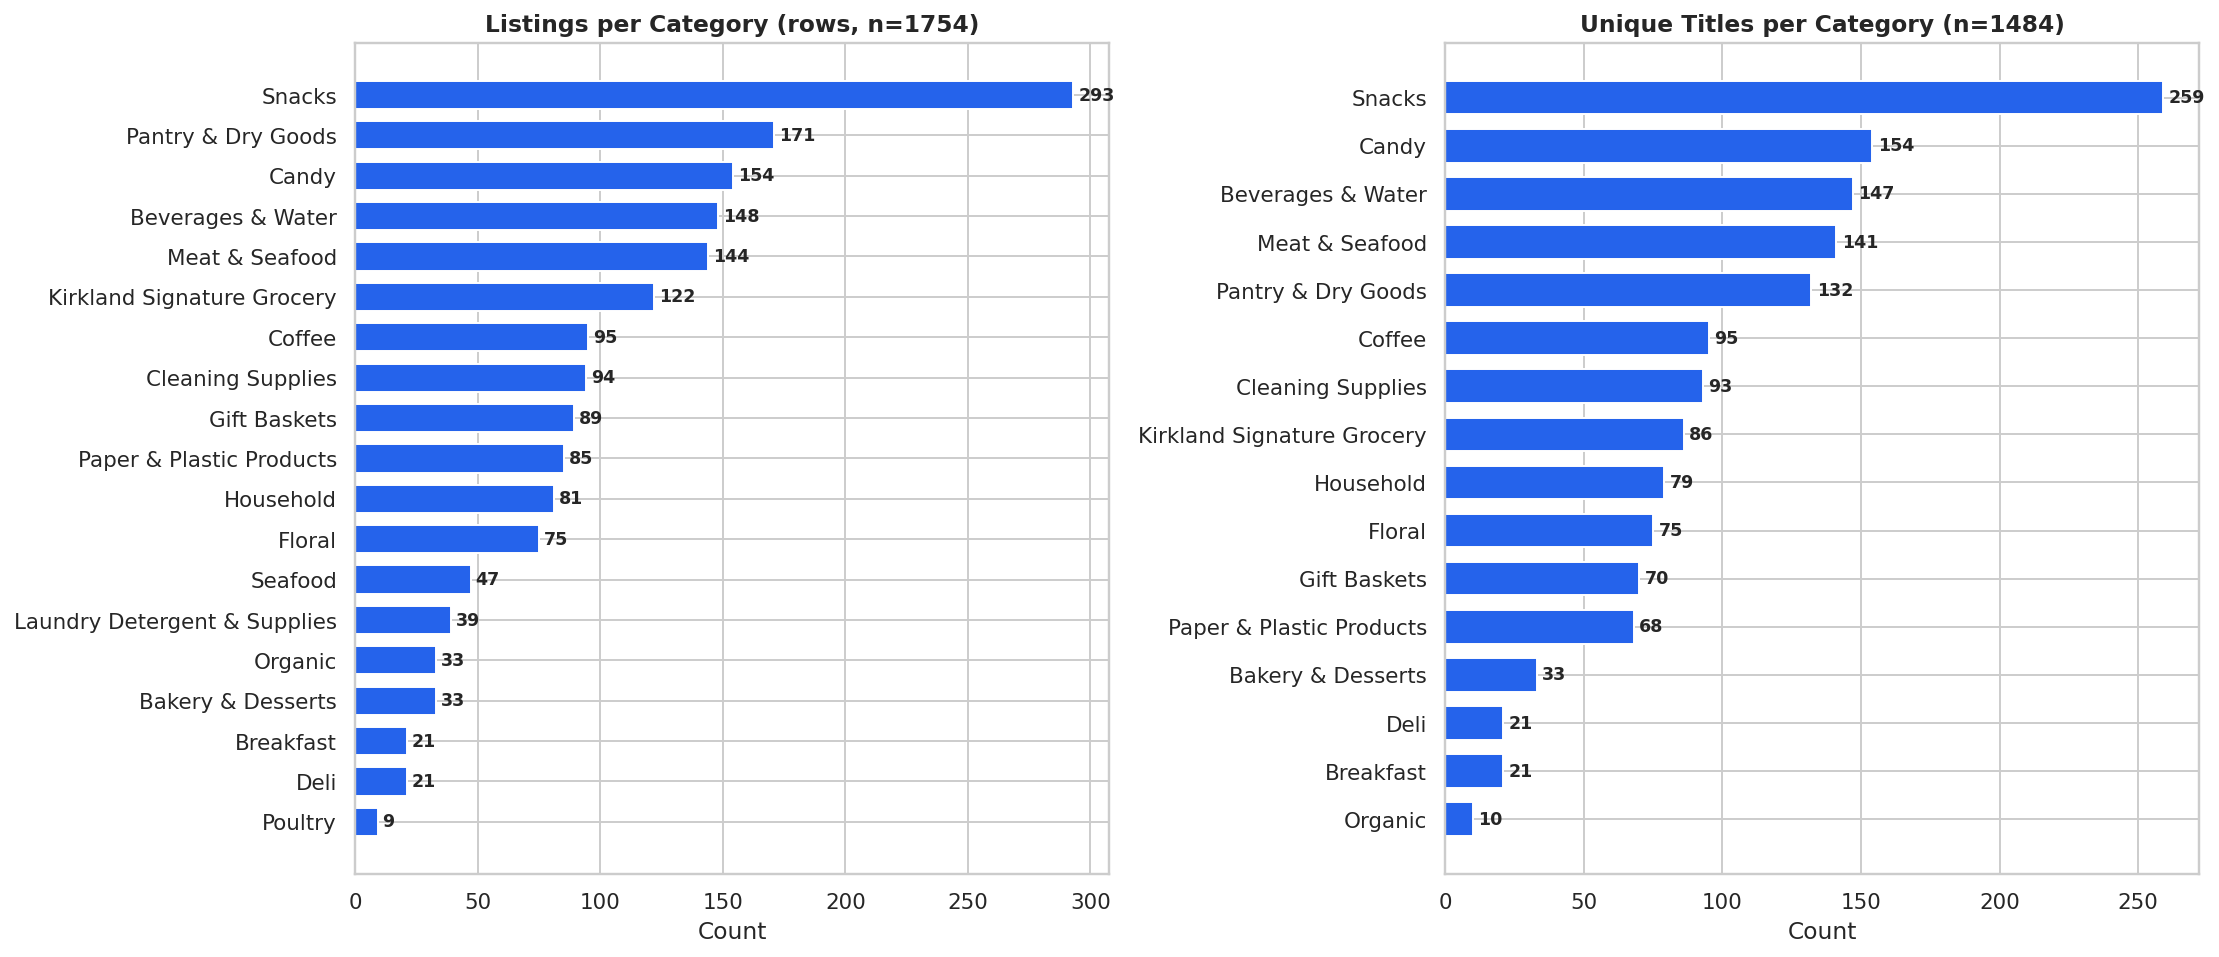

In [31]:
cat_raw = df['category'].value_counts()
cat_unique = df.drop_duplicates(subset='Title', keep='first')['category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax_i, (data, title) in enumerate([
    (cat_raw, f'Listings per Category (rows, n={len(df)})'),
    (cat_unique, f'Unique Titles per Category (n={df["Title"].nunique()})')
]):
    ax = axes[ax_i]
    data_sorted = data.sort_values()
    bars = ax.barh(data_sorted.index, data_sorted.values, color=BLUE,
                   edgecolor='white', height=0.7)
    for bar, val in zip(bars, data_sorted.values):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Count')

plt.tight_layout()
plt.savefig('/home/claude/fig_05_category_freq.png', bbox_inches='tight')
plt.show()

**Note the shift when deduplicating:** Kirkland Signature Grocery drops from 122 rows
to 86 unique titles, losing the most from cross-listing. "Seafood" drops sharply
because nearly all its products are also listed under "Meat & Seafood."

---
## 3 · Cross-Category & Normalized Analysis

### 3.1 — Normalized Category Metrics (rated products only)

To avoid "big category = best category" bias, we report per-product
medians alongside sample sizes.

In [ ]:
cat_metrics = (rated.groupby('category')
               .agg(
                   n_rated=('rating', 'count'),
                   median_price=('price', 'median'),
                   median_rating=('rating', 'median'),
                   mean_rating=('rating', 'mean'),
                   median_reviews=('review_count', 'median'),
                   total_reviews=('review_count', 'sum'),
                   discount_rate=('has_discount', 'mean'),
               )
               .round(2))

# Add total listings and coverage
cat_totals = df.groupby('category').size().rename('total_listings')
cat_metrics = cat_metrics.join(cat_totals)
cat_metrics['rating_coverage'] = (cat_metrics['n_rated'] / cat_metrics['total_listings'] * 100).round(1)
cat_metrics['reviews_per_product'] = (cat_metrics['total_reviews'] / cat_metrics['n_rated']).round(0)
cat_metrics = cat_metrics.sort_values('median_reviews', ascending=False)

print("NORMALIZED CATEGORY METRICS (sorted by median reviews per product)")
print("="*110)
print(cat_metrics[['n_rated','total_listings','rating_coverage',
                   'median_price','mean_rating','median_reviews',
                   'reviews_per_product','discount_rate']].to_string())

In [ ]:
plot_data = cat_metrics.query('n_rated >= 3').sort_values('median_reviews')

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(plot_data.index, plot_data['median_reviews'], color=BLUE,
               edgecolor='white', height=0.7)
for bar, (idx, row) in zip(bars, plot_data.iterrows()):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f"{row['median_reviews']:.0f}  (n={int(row['n_rated'])}, "
            f"coverage={row['rating_coverage']:.0f}%)",
            va='center', fontsize=8, color='#334155')
ax.set_title('Median Reviews per Product by Category\n'
             '(only categories with ≥ 3 rated products; n = rated count)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Median Review Count')
plt.tight_layout()
plt.savefig('/home/claude/fig_06_median_reviews_cat.png', bbox_inches='tight')
plt.show()

In [ ]:
order = df.groupby('category')['price'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(data=df, y='category', x='price', order=order,
            palette='viridis', ax=ax, fliersize=2, linewidth=0.7,
            showmeans=False)
ax.set_xlim(0, 500)
ax.set_title('Price Distribution by Category (capped at $500 for readability)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Price ($)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('/home/claude/fig_07_price_by_cat.png', bbox_inches='tight')
plt.show()

### 3.4 — Product Family Analysis

The catalog mixes very different product worlds. Grouping into families
produces more meaningful comparisons than treating all 19 categories as equals.

**Family mapping methodology:** Categories were grouped by product function and
buying behavior. Food & Beverage includes all edible/drinkable categories.
Protein & Perishable groups the high-price, fresh/frozen items that share
similar fulfillment constraints. Household & Cleaning covers non-food consumables.
Gifting & Premium groups products bought primarily as gifts (Floral + Gift Baskets).
Kirkland Signature Grocery is kept separate because it is a private-label brand
that cross-lists into multiple functional categories. The mapping is shown below.

In [ ]:
print("FAMILY DEFINITIONS (analyst-defined groupings):")
family_map = {
    'Food & Beverage': ['Snacks','Pantry & Dry Goods','Candy','Beverages & Water',
                        'Coffee','Bakery & Desserts','Breakfast','Deli','Organic'],
    'Protein & Perishable': ['Meat & Seafood','Seafood','Poultry'],
    'Household & Cleaning': ['Cleaning Supplies','Household','Paper & Plastic Products',
                             'Laundry Detergent & Supplies'],
    'Gifting & Premium': ['Gift Baskets','Floral'],
    'Private Label (Kirkland)': ['Kirkland Signature Grocery'],
}
for fam, cats in family_map.items():
    print(f"  {fam}: {', '.join(cats)}")

df['family'] = 'Other'
for fam, cats in family_map.items():
    df.loc[df['category'].isin(cats), 'family'] = fam

fam_stats = []
for fam in family_map:
    sub = df[df['family'] == fam]
    r = sub.dropna(subset=['rating'])
    fam_stats.append({
        'Family': fam,
        'Listings': len(sub),
        'Unique Titles': sub['Title'].nunique(),
        'Rating Coverage': f"{len(r)/len(sub)*100:.0f}%",
        'Median Price': f"${sub['price'].median():.0f}",
        'Mean Rating': f"{r['rating'].mean():.2f}" if len(r) > 0 else 'N/A',
        'Median Reviews': f"{r['review_count'].median():.0f}" if len(r) > 0 else 'N/A',
        'Discount Rate': f"{sub['has_discount'].mean()*100:.1f}%",
    })

fam_df = pd.DataFrame(fam_stats)
print("PRODUCT FAMILY COMPARISON")
print("=" * 100)
print(fam_df.to_string(index=False))

**Key observations by family:**
- **Protein & Perishable** has the highest prices (median $200) and best rating
  coverage (90%), but lower engagement per product — customers buy but don't
  review seafood/meat as frequently.
- **Gifting & Premium** (Gift Baskets + Floral) has the highest engagement per product
  (median 553 reviews) and 80% coverage. Flowers are reviewed *far* more than
  most grocery items.
- **Private Label (Kirkland)** stands out with the highest mean rating (4.61)
  and highest median reviews (2,218) among the 19 rated products — but only 16%
  rating coverage, so this is based on a small, potentially non-representative sample.

---
## 3.5 — Discount Analysis (Stratified)

Only **123 listings** (7%) carry a discount. Of these, only **28 have ratings**.
This limits the power of any discount–engagement comparison.

DISCOUNT OVERVIEW
  Discounted listings: 123 / 1754 (7.0%)
  Discount amount: median=$4.10, mean=$11.46
  Discount as % of price: median=25.0%, mean=25.8%
  Discounted products WITH ratings: 28


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/fig_08_discount_by_cat.png'

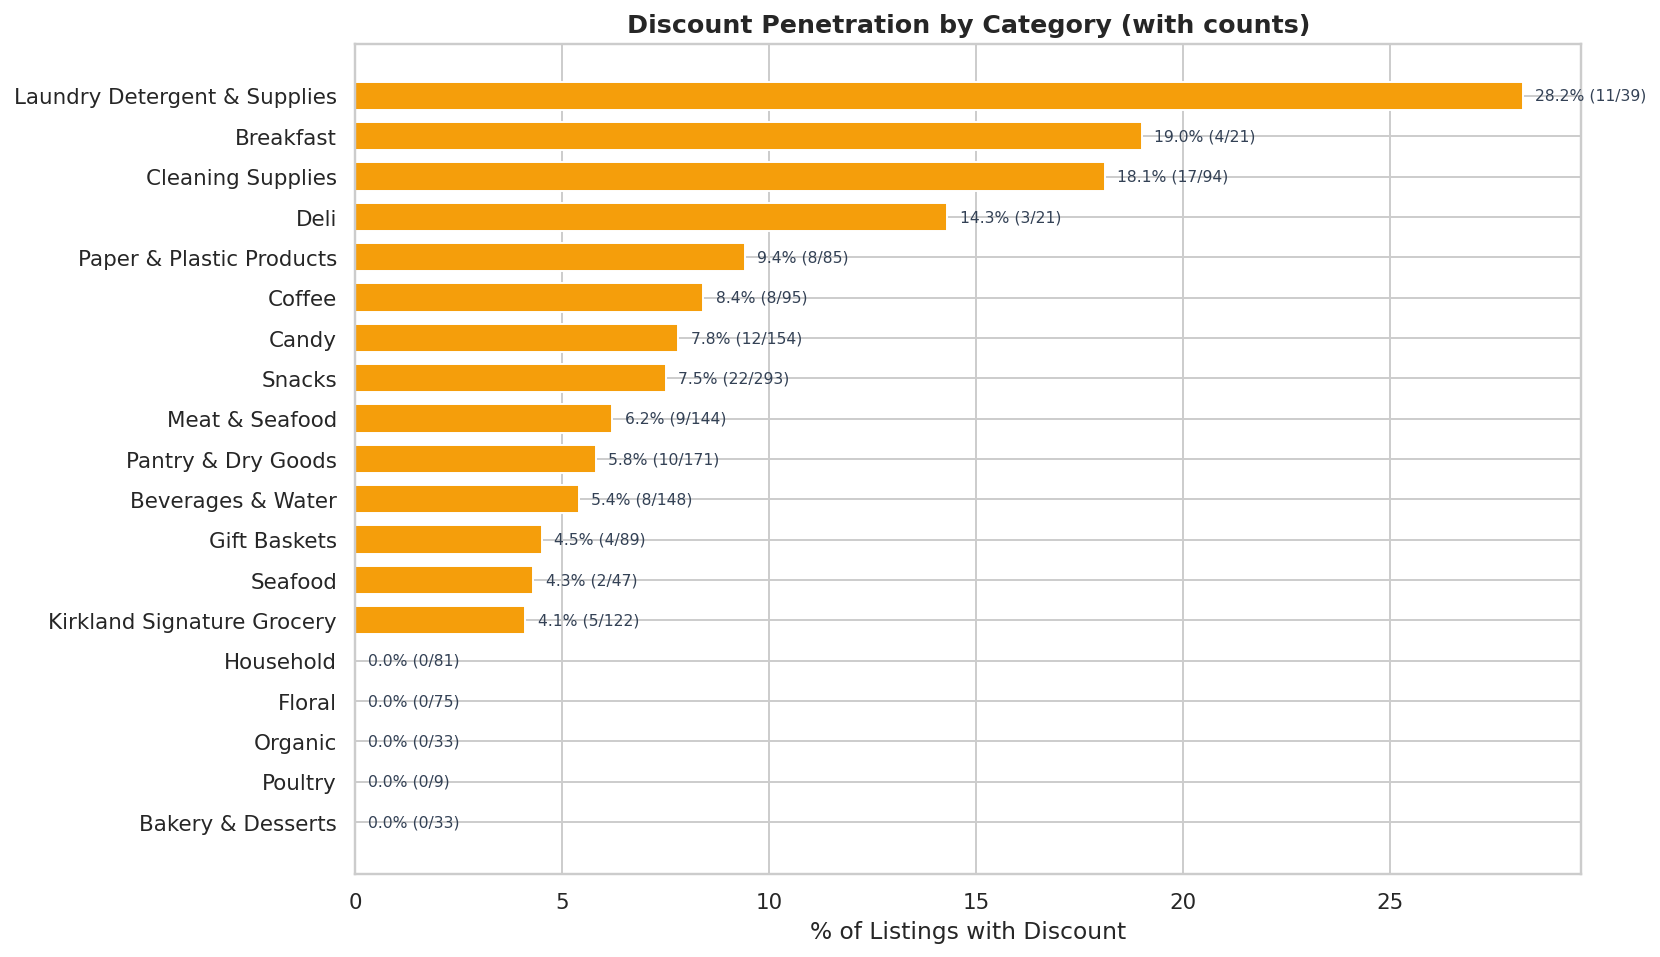

In [32]:
print("DISCOUNT OVERVIEW")
print(f"  Discounted listings: {df['has_discount'].sum()} / {len(df)} ({df['has_discount'].mean()*100:.1f}%)")
disc = df[df['has_discount']]
print(f"  Discount amount: median=${disc['discount_amt'].median():.2f}, "
      f"mean=${disc['discount_amt'].mean():.2f}")
print(f"  Discount as % of price: median={disc['discount_pct'].median():.1f}%, "
      f"mean={disc['discount_pct'].mean():.1f}%")
print(f"  Discounted products WITH ratings: {disc['rating'].notna().sum()}")

# Discount by category
disc_by_cat = (df.groupby('category')
               .agg(total=('has_discount','count'),
                    n_discounted=('has_discount','sum'))
               .assign(disc_rate=lambda x: (x.n_discounted / x.total * 100).round(1))
               .sort_values('disc_rate', ascending=True))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(disc_by_cat.index, disc_by_cat['disc_rate'], color=AMBER,
               edgecolor='white', height=0.7)
for bar, (idx, row) in zip(bars, disc_by_cat.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{row['disc_rate']:.1f}% ({int(row['n_discounted'])}/{int(row['total'])})",
            va='center', fontsize=8, color='#334155')
ax.set_title('Discount Penetration by Category (with counts)', fontweight='bold', fontsize=13)
ax.set_xlabel('% of Listings with Discount')
plt.tight_layout()
plt.savefig('/home/claude/fig_08_discount_by_cat.png', bbox_inches='tight')
plt.show()

In [ ]:
bins = [0, 20, 50, 100, 200, 2000]
labels_tier = ['$0-20', '$20-50', '$50-100', '$100-200', '$200+']
rated_tier = rated.copy()
rated_tier['price_tier'] = pd.cut(rated_tier['price'], bins=bins, labels=labels_tier, right=True)

print("\nSTRATIFIED DISCOUNT vs NON-DISCOUNT (by price tier, rated products only)")
print("-" * 80)
strat = []
for tier in labels_tier:
    sub = rated_tier[rated_tier['price_tier'] == tier]
    d = sub[sub['has_discount']]
    nd = sub[~sub['has_discount']]
    strat.append({
        'Tier': tier,
        'Discounted n': len(d),
        'Disc Median Rev': f"{d['review_count'].median():.0f}" if len(d) > 0 else '—',
        'Non-Disc n': len(nd),
        'Non-Disc Median Rev': f"{nd['review_count'].median():.0f}" if len(nd) > 0 else '—',
    })
strat_df = pd.DataFrame(strat)
print(strat_df.to_string(index=False))

**Honest assessment:** The discounted sample is too small (n=28 rated) to make
strong claims. Directionally, discounted products in the $20–50 and $100–200 tiers
show higher median reviews, but with n=7 and n=9 respectively, this is suggestive
at best. **We cannot conclude that "discounts drive trial"** from this data alone.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(disc['discount_amt'], bins=20, color=AMBER, edgecolor='white', alpha=0.85)
ax.set_title(f'Discount Amount Distribution (n={len(disc)})', fontweight='bold')
ax.set_xlabel('Discount ($)')
ax.set_ylabel('Count')

ax = axes[1]
ax.hist(disc['discount_pct'], bins=20, color=RED, edgecolor='white', alpha=0.85)
ax.set_title('Discount as % of Price', fontweight='bold')
ax.set_xlabel('Discount %')
ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('/home/claude/fig_09_discount_depth.png', bbox_inches='tight')
plt.show()

print(f"Discount depth: Most discounts are 20–30% off (median {disc['discount_pct'].median():.0f}%)")

---
## 4 · Text Mining & Brand Analysis

### 4.1 — Kirkland Signature vs. All Other Brands

In [ ]:
# NOTE: "Kirkland" exists at two levels in this dataset:
#   1. The CATEGORY "Kirkland Signature Grocery" (122 rows, 19 rated)
#   2. The BRAND — any product title containing "Kirkland" across ALL categories
# Below we analyze at the brand level, which is the more meaningful comparison.

is_kirkland = df['Title'].str.lower().str.contains('kirkland', na=False)

print("KIRKLAND: CATEGORY vs BRAND — WHY THE NUMBERS DIFFER")
print("=" * 80)
kirk_cat = df[df['category'] == 'Kirkland Signature Grocery']
print(f"  'Kirkland Signature Grocery' CATEGORY:")
print(f"    Rows: {len(kirk_cat)}, Unique titles: {kirk_cat['Title'].nunique()}, "
      f"Rated: {kirk_cat['rating'].notna().sum()}, Coverage: {kirk_cat['rating'].notna().mean()*100:.1f}%")

kirk_brand = df[is_kirkland]
kirk_brand_dedup = kirk_brand.drop_duplicates(subset='Title')
kirk_brand_rated = kirk_brand_dedup.dropna(subset=['rating'])
non_kirk = df[~is_kirkland]
non_kirk_dedup = non_kirk.drop_duplicates(subset='Title')
non_kirk_rated = non_kirk_dedup.dropna(subset=['rating'])

print(f"\n  Kirkland as BRAND (across all categories):")
print(f"    Rows: {len(kirk_brand)}, Unique titles: {len(kirk_brand_dedup)}, "
      f"Rated titles: {len(kirk_brand_rated)}, "
      f"Coverage: {len(kirk_brand_rated)/len(kirk_brand_dedup)*100:.1f}%")
print(f"  The difference: {len(kirk_brand) - len(kirk_brand_dedup)} extra rows come from "
      f"Kirkland products cross-listed into Pantry, Snacks, Coffee, Organic, etc.")

kirk_stats = {}
for label, dedup, rated_d in [
    ('Kirkland (brand)', kirk_brand_dedup, kirk_brand_rated),
    ('Non-Kirkland', non_kirk_dedup, non_kirk_rated)
]:
    kirk_stats[label] = {
        'Unique Titles': len(dedup),
        'Rating Coverage': f"{len(rated_d)/len(dedup)*100:.0f}% (n={len(rated_d)} rated)",
        'Median Price': f"${dedup['price'].median():.2f}",
        'Mean Rating': f"{rated_d['rating'].mean():.2f}" if len(rated_d) > 0 else 'N/A',
        'Median Reviews': f"{rated_d['review_count'].median():.0f}" if len(rated_d) > 0 else 'N/A',
        'Discount Rate': f"{dedup['has_discount'].mean()*100:.1f}%",
    }

kirk_df = pd.DataFrame(kirk_stats).T
print(f"\nBRAND-LEVEL COMPARISON (deduplicated by title)")
print("=" * 80)
print(kirk_df.to_string())

**Kirkland findings (with caveats):**
- Kirkland has **159 unique products** across the catalog, priced lower (median $17 vs $29).
- Among the **27 unique rated Kirkland titles** (17% coverage), the **mean rating is 4.60**
  (vs 4.33 for non-Kirkland) and **median reviews are 1,957** (vs 184 for non-Kirkland).
- **Why the numbers differ from the category table:** The "Kirkland Signature Grocery"
  category contains 122 rows with 19 rated. The brand-level analysis captures an additional
  37 unique Kirkland titles that are only listed under functional categories (Snacks, Coffee, etc.)
  and not in the Kirkland category itself.
- **However:** 17% coverage means the rated subset likely skews toward
  the brand's most popular items, so the true advantage could be smaller.

In [33]:
text_col = (df['Title'].fillna('') + ' ' + df['Feature'].fillna('') +
            ' ' + df['Product Description'].fillna('')).str.lower()

keywords = {
    'organic': r'\borganic\b',
    'gluten-free': r'\bgluten[\s-]?free\b',
    'protein': r'\bprotein\b',
    'gift': r'\bgift\b',
    'bundle/pack': r'\b(pack|bundle|combo|variety)\b',
    'kosher': r'\bkosher\b',
    'non-gmo': r'\bnon[\s-]?gmo\b',
    'vegan': r'\bvegan\b',
    'keto': r'\bketo\b',
    'sugar-free': r'\bsugar[\s-]?free\b',
}

kw_results = []
for kw, pattern in keywords.items():
    mask = text_col.str.contains(pattern, na=False)
    n = mask.sum()
    sub_rated = df[mask].dropna(subset=['rating'])
    kw_results.append({
        'Keyword': kw,
        'Products': n,
        'Pct of Catalog': f"{n/len(df)*100:.1f}%",
        'Median Price': f"${df[mask]['price'].median():.0f}",
        'Rated (n)': len(sub_rated),
        'Median Reviews': f"{sub_rated['review_count'].median():.0f}" if len(sub_rated) > 0 else '—',
        'Mean Rating': f"{sub_rated['rating'].mean():.2f}" if len(sub_rated) > 0 else '—',
    })

kw_df = pd.DataFrame(kw_results).sort_values('Products', ascending=False)
print("KEYWORD / ATTRIBUTE ANALYSIS")
print("=" * 100)
print(kw_df.to_string(index=False))

KEYWORD / ATTRIBUTE ANALYSIS
    Keyword  Products Pct of Catalog Median Price  Rated (n) Median Reviews Mean Rating
bundle/pack       596          34.0%          $40        325            220        4.37
     kosher       459          26.2%          $18         89            454        4.51
gluten-free       268          15.3%          $22         85             90        4.42
    organic       171           9.7%          $18         60            447        4.54
       gift       162           9.2%          $60        125            543        4.35
    non-gmo       151           8.6%          $25         65            226        4.42
    protein       117           6.7%          $24         49            128        4.48
      vegan        64           3.6%          $26         27             29        4.18
 sugar-free        35           2.0%          $17          5             12        4.10
       keto        28           1.6%          $38         22             80        4.20


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/fig_10_keywords.png'

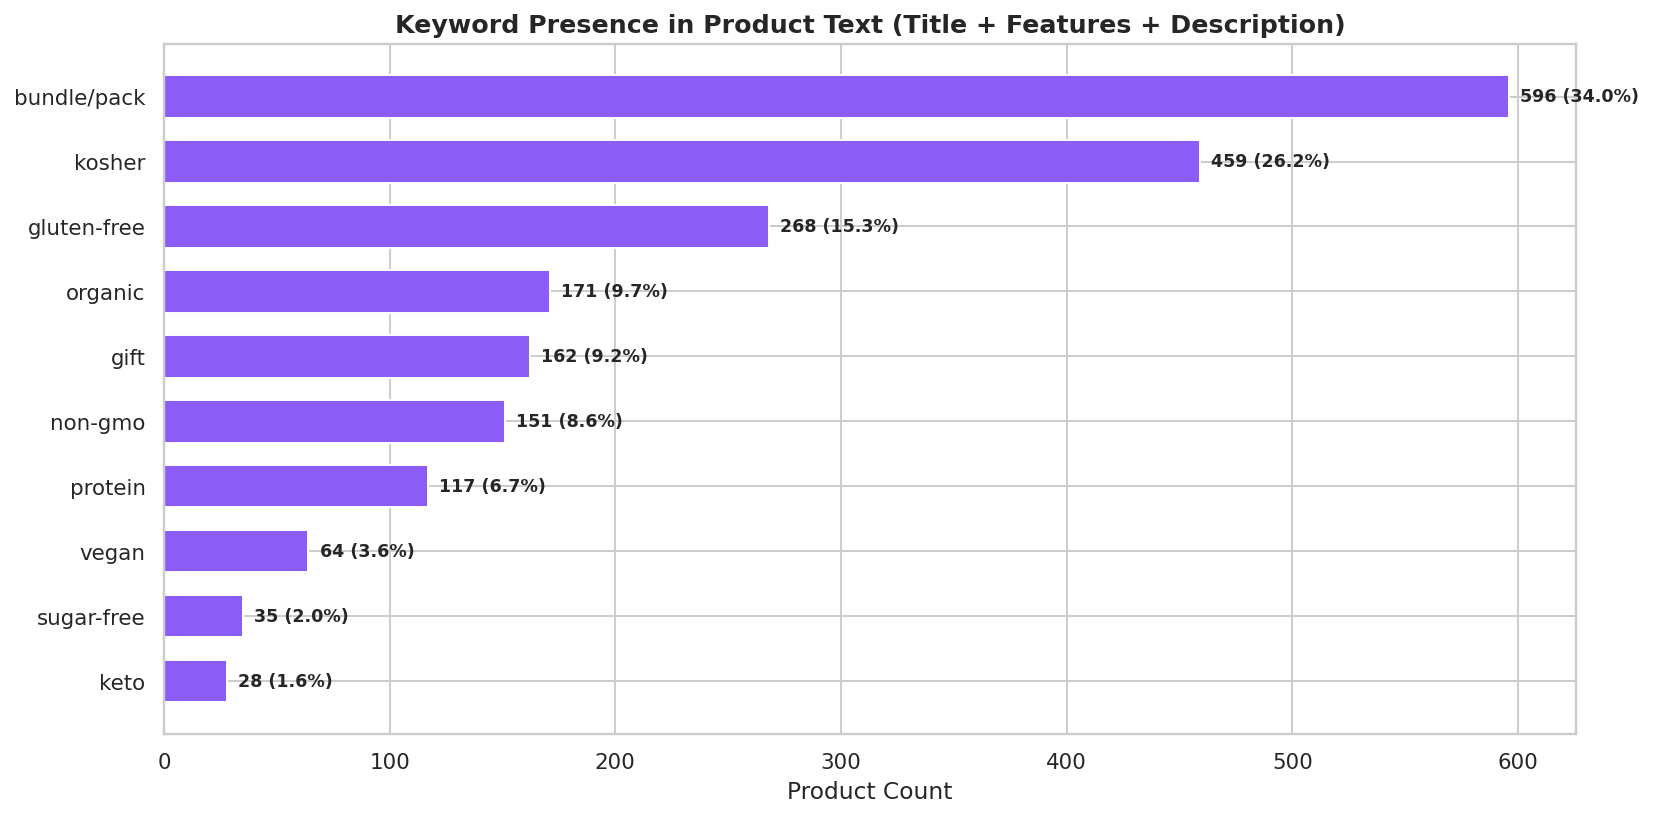

In [34]:
kw_plot = kw_df.set_index('Keyword')
fig, ax = plt.subplots(figsize=(12, 6))
vals = kw_plot['Products'].sort_values()
ax.barh(vals.index, vals.values, color=PURPLE, edgecolor='white', height=0.65)
for i, (idx, val) in enumerate(vals.items()):
    pct = kw_plot.loc[idx, 'Pct of Catalog']
    ax.text(val + 5, i, f"{val} ({pct})", va='center', fontsize=9, fontweight='bold')
ax.set_title('Keyword Presence in Product Text (Title + Features + Description)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Product Count')
plt.tight_layout()
plt.savefig('/home/claude/fig_10_keywords.png', bbox_inches='tight')
plt.show()

**Notable patterns:**
- **"bundle/pack"** appears in 34% of listings — this is fundamentally a bulk/wholesale catalog.
- **"kosher"** certification is common (26%), reflecting the retailer's food focus.
- **"organic"** products command similar prices but show stronger engagement (median 447 reviews, n=34 rated).
- Emerging diet trends (keto, vegan, sugar-free) have small footprints (< 4%).

---
## 5 · Product Opportunity Analysis

### 5.1 — Top 10 Most-Reviewed Products (actual data)

In [ ]:
top_reviewed = (df.dropna(subset=['review_count'])
                .nlargest(10, 'review_count')
                .drop_duplicates(subset='Title', keep='first'))

fig, ax = plt.subplots(figsize=(14, 6))
labels = top_reviewed['Title'].str[:50].values
reviews = top_reviewed['review_count'].values
cats = top_reviewed['category'].values
colors_map = {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(df['category'].unique())}
bar_colors = [colors_map.get(c, GRAY) for c in cats]

bars = ax.barh(range(len(labels))[::-1], reviews,
               color=bar_colors[::-1], edgecolor='white', height=0.65)
ax.set_yticks(range(len(labels))[::-1])
ax.set_yticklabels(labels[::-1], fontsize=8)
for bar, rev, cat in zip(bars, reviews[::-1], cats[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f"{rev:,.0f}  [{cat}]", va='center', fontsize=8, fontweight='bold')
ax.set_title('Top 10 Most-Reviewed Products (from actual dataset)', fontweight='bold', fontsize=13)
ax.set_xlabel('Review Count')
plt.tight_layout()
plt.savefig('/home/claude/fig_11_top_reviewed.png', bbox_inches='tight')
plt.show()

print("Note: 5 of the top 10 most-reviewed products are Floral items (roses/arrangements).")
print("This reflects the 'gifting' nature of these products — buyers review gifts more.")

### 5.2 — Product Opportunity Segments

**Threshold methodology:** The cutoffs below are anchored to this dataset's
distribution percentiles, not arbitrary round numbers:
- **Hidden Gems** use rating ≥ 4.5 (the 75th percentile of ratings) and
  reviews < 100 (below the 25th percentile of review counts, which is 41).
  The price > $10 filter excludes trivial low-cost items.
- **Risk Items** use price ≥ $80 (approximately the 60th percentile) and
  rating < 4.0 (well below the dataset mean of 4.36). These are products
  where the customer is paying a premium but reporting low satisfaction.
- **Unrated High-Value** requires no threshold — it captures all products
  with zero ratings, prioritized by price.

In [35]:
print("THRESHOLD CONTEXT (from dataset percentiles):")
print(f"  Rating P75 = {rated['rating'].quantile(0.75):.2f} → Hidden Gem cutoff: ≥ 4.5")
print(f"  Review P25 = {rated['review_count'].quantile(0.25):.0f} → Hidden Gem cutoff: < 100")
print(f"  Price  P75 = ${rated['price'].quantile(0.75):.0f} → Risk Item cutoff: ≥ $80")
print(f"  Rating mean = {rated['rating'].mean():.2f} → Risk Item cutoff: < 4.0\n")

gems = (rated.query('rating >= 4.5 and review_count < 100 and review_count >= 3 and price > 10')
        .sort_values('rating', ascending=False)
        .drop_duplicates(subset='Title')
        .head(12))

print("\nHIDDEN GEMS: High-rated (≥ 4.5), low reviews (3–100), price > $10")
print("-" * 90)
for _, r in gems.iterrows():
    print(f"  ★{r.rating} ({r.review_count:.0f} rev) ${r.price:.0f} "
          f"| {r.category} | {r.Title[:65]}")
print(f"\nTotal hidden gems matching criteria: {len(rated.query('rating >= 4.5 and review_count < 100 and review_count >= 3 and price > 10'))}")

THRESHOLD CONTEXT (from dataset percentiles):
  Rating P75 = 4.60 → Hidden Gem cutoff: ≥ 4.5
  Review P25 = 41 → Hidden Gem cutoff: < 100
  Price  P75 = $160 → Risk Item cutoff: ≥ $80
  Rating mean = 4.34 → Risk Item cutoff: < 4.0


HIDDEN GEMS: High-rated (≥ 4.5), low reviews (3–100), price > $10
------------------------------------------------------------------------------------------
  ★5.0 (3 rev) $29 | Paper & Plastic Products | Artstyle Paper Plate & Napkin Bundle, Year of the Dragon Lunar Ne
  ★5.0 (6 rev) $100 | Beverages & Water | Pulp & Press Organic Cold-Pressed Juice Variety Pack, 18-pack
  ★5.0 (6 rev) $65 | Meat & Seafood | Sampler: Dry-Cured Acorn-Fed 100% Iberico Pork Ham and Salami and
  ★5.0 (3 rev) $45 | Pantry & Dry Goods | eat.art Salt and Spice Set 2-pack
  ★5.0 (3 rev) $150 | Gift Baskets | Jacques Torres Assorted Chocolate Large Hat Box
  ★5.0 (11 rev) $50 | Snacks | G2G 3-pack Almond Chocolate Chip Protein Bars, 24-count
  ★5.0 (4 rev) $80 | Paper & Plastic Pro

In [36]:
risk = (rated.query('price >= 80 and rating < 4.0')
        .sort_values('rating')
        .drop_duplicates(subset='Title')
        .head(10))

print("\nRISK ITEMS: Price ≥ $80, rating < 4.0")
print("-" * 90)
for _, r in risk.iterrows():
    print(f"  ★{r.rating} ({r.review_count:.0f} rev) ${r.price:.0f} "
          f"| {r.category} | {r.Title[:65]}")
n_risk = len(rated.query('price >= 80 and rating < 4.0').drop_duplicates(subset='Title'))
print(f"\nTotal risk items: {n_risk}")


RISK ITEMS: Price ≥ $80, rating < 4.0
------------------------------------------------------------------------------------------
  ★1.0 (1 rev) $170 | Seafood | Aysen Coho Sashimi Quality Salmon Portions, (6 Oz. Portion Per Pa
  ★1.0 (1 rev) $340 | Meat & Seafood | Authentic Wagyu Surf & Turf Pack, (2/17-20 Oz. Cold Water Lobster
  ★1.5 (2 rev) $160 | Bakery & Desserts | The Cake Bake Shop 8" Round Pixie Fetti Cake (16-22 Servings)
  ★2.2 (4 rev) $120 | Bakery & Desserts | Ferrara's Bakery 48 Mini Cannoli's (24 Plain Filled and 24 Hand D
  ★2.6 (18 rev) $250 | Meat & Seafood | Authentic Wagyu Japanese A5 Bacon Wrapped Cubes, (3/16 Cubes Per 
  ★2.8 (5 rev) $260 | Meat & Seafood | Whole Cooked Cold Water Lobsters, (8-9/1.25 Lbs. Each Lobster), 1
  ★2.9 (64 rev) $180 | Seafood | Coastal Seafood Live Maine Lobsters, (6/1.25 Lbs. Per Lobster) 6 
  ★3.0 (55 rev) $170 | Meat & Seafood | Quality Ethnic Foods Half Goat Meat Locker - 10 Total Packs, 15 L
  ★3.0 (1 rev) $300 | Bakery & Desserts

In [37]:
unrated = df[df['rating'].isna()].copy()
unrated_targets = unrated.nlargest(15, 'price').drop_duplicates(subset='Title').head(10)

print(f"\nUNRATED REVIEW TARGETS: Highest-price products with no ratings")
print(f"(Total unrated: {unrated['Title'].nunique()} unique titles, "
      f"{len(unrated)} rows)")
print("-" * 90)
for _, r in unrated_targets.iterrows():
    print(f"  ${r.price:.0f} | {r.category} | {r.Title[:70]}")


UNRATED REVIEW TARGETS: Highest-price products with no ratings
(Total unrated: 974 unique titles, 1137 rows)
------------------------------------------------------------------------------------------
  $280 | Meat & Seafood | Authentic Wagyu Surf & Turf Pack, (2/17-20 Oz./Each Tail) Cold Water L
  $280 | Meat & Seafood | Wild Alaska Snow Crab Meat (Bairdi Crab 8 oz. Pack) 12 Total Packs, 6 
  $260 | Meat & Seafood | Lobster With Shell Removed, (9 Oz. Per Pack), 6 Total Packs, 3.44 Lbs.
  $240 | Meat & Seafood | Ahi Tuna Mixed Pack, (12 x 6 oz. Steaks, 9 x 5.3 oz. Saku Slice Packs,
  $240 | Meat & Seafood | D’Artagnan ABF Butcher Box Collection, Total 7.5lbs
  $230 | Meat & Seafood | Chicago Steak USDA Prime Beef Wet Aged Boneless Strips & Gourmet Burge
  $200 | Meat & Seafood | Lobster Claws & Arms, Sustainable Wild Caught, North Atlantic, 24-40 C
  $190 | Pantry & Dry Goods | European Black Winter Fresh Truffles 3 oz.
  $170 | Meat & Seafood | Kansas City Steak Company USDA Choice Fi

### 5.5 — Correlation Analysis

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/fig_12_correlation.png'

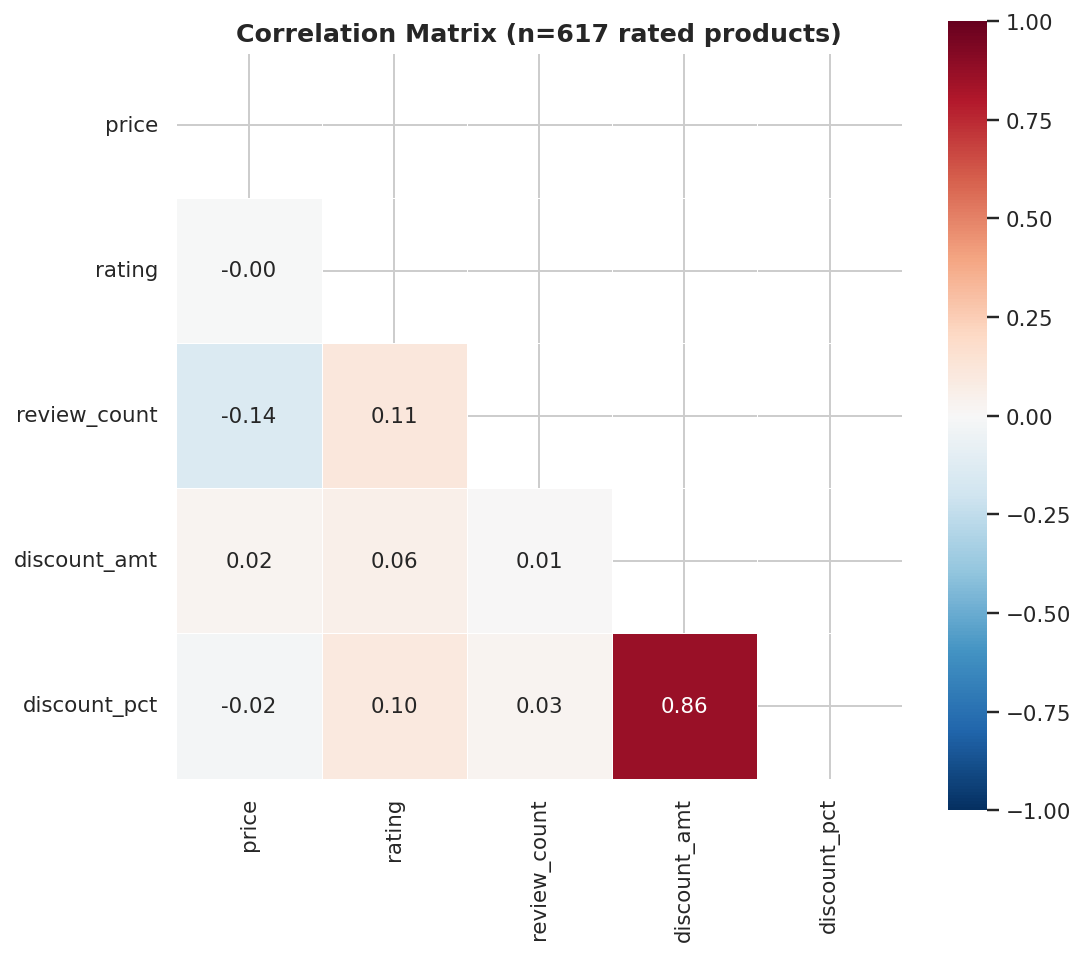

In [38]:
numeric_cols = ['price', 'rating', 'review_count', 'discount_amt', 'discount_pct']
corr = rated[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, square=True, vmin=-1, vmax=1,
            annot_kws={'size': 11})
ax.set_title(f'Correlation Matrix (n={len(rated)} rated products)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('/home/claude/fig_12_correlation.png', bbox_inches='tight')
plt.show()

print(f"Key correlations (n={len(rated)}):")
print(f"  price ↔ rating:       r = {corr.loc['price','rating']:.3f}  (negligible)")
print(f"  price ↔ reviews:      r = {corr.loc['price','review_count']:.3f}  (weak negative)")
print(f"  price ↔ discount_amt: r = {corr.loc['price','discount_amt']:.3f}  (negligible)")
print(f"  rating ↔ reviews:     r = {corr.loc['rating','review_count']:.3f}  (weak)")

**Interpretation:**
- **Price and rating are uncorrelated** (r ≈ 0.00). Higher-priced products are not
  rated any better or worse.
- **Price and discount amount are negligibly correlated** (r ≈ 0.02). Despite
  expectations, higher-priced items do not consistently carry larger discounts in
  this catalog — likely because discounts are sparse (only 28 rated products).
- **Rating and review count are weakly correlated** (r ≈ 0.11). Popularity
  does not strongly predict satisfaction or vice versa.
- **Price and review count show a weak negative relationship** (r ≈ −0.14),
  suggesting that lower-priced items accumulate somewhat more reviews.

### 5.6 — Sensitivity Check: Do Category Rankings Change When Cross-Listed Titles Are Collapsed?

In [39]:
df_dedup = df.drop_duplicates(subset='Title', keep='first')

print("SENSITIVITY: CATEGORY RANKINGS — ALL ROWS vs UNIQUE TITLES")
print("=" * 80)
raw_rank = df['category'].value_counts().reset_index()
raw_rank.columns = ['category', 'raw_count']
raw_rank['raw_rank'] = range(1, len(raw_rank) + 1)

dedup_rank = df_dedup['category'].value_counts().reset_index()
dedup_rank.columns = ['category', 'dedup_count']
dedup_rank['dedup_rank'] = range(1, len(dedup_rank) + 1)

merged = raw_rank.merge(dedup_rank, on='category')
merged['rank_change'] = merged['raw_rank'] - merged['dedup_rank']
merged['lost_rows'] = merged['raw_count'] - merged['dedup_count']
print(merged.sort_values('raw_rank').to_string(index=False))

print(f"\nCategories that change rank by ≥ 2 positions:")
movers = merged[merged['rank_change'].abs() >= 2].sort_values('rank_change')
for _, r in movers.iterrows():
    direction = "↑" if r.rank_change > 0 else "↓"
    print(f"  {r.category}: #{r.raw_rank} → #{r.dedup_rank} ({direction}{abs(r.rank_change)}) "
          f"[lost {r.lost_rows} cross-listed rows]")

SENSITIVITY: CATEGORY RANKINGS — ALL ROWS vs UNIQUE TITLES
                  category  raw_count  raw_rank  dedup_count  dedup_rank  rank_change  lost_rows
                    Snacks        293         1          259           1            0         34
        Pantry & Dry Goods        171         2          132           5           -3         39
                     Candy        154         3          154           2            1          0
         Beverages & Water        148         4          147           3            1          1
            Meat & Seafood        144         5          141           4            1          3
Kirkland Signature Grocery        122         6           86           8           -2         36
                    Coffee         95         7           95           6            1          0
         Cleaning Supplies         94         8           93           7            1          1
              Gift Baskets         89         9           70        

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/fig_13_rank_robustness.png'

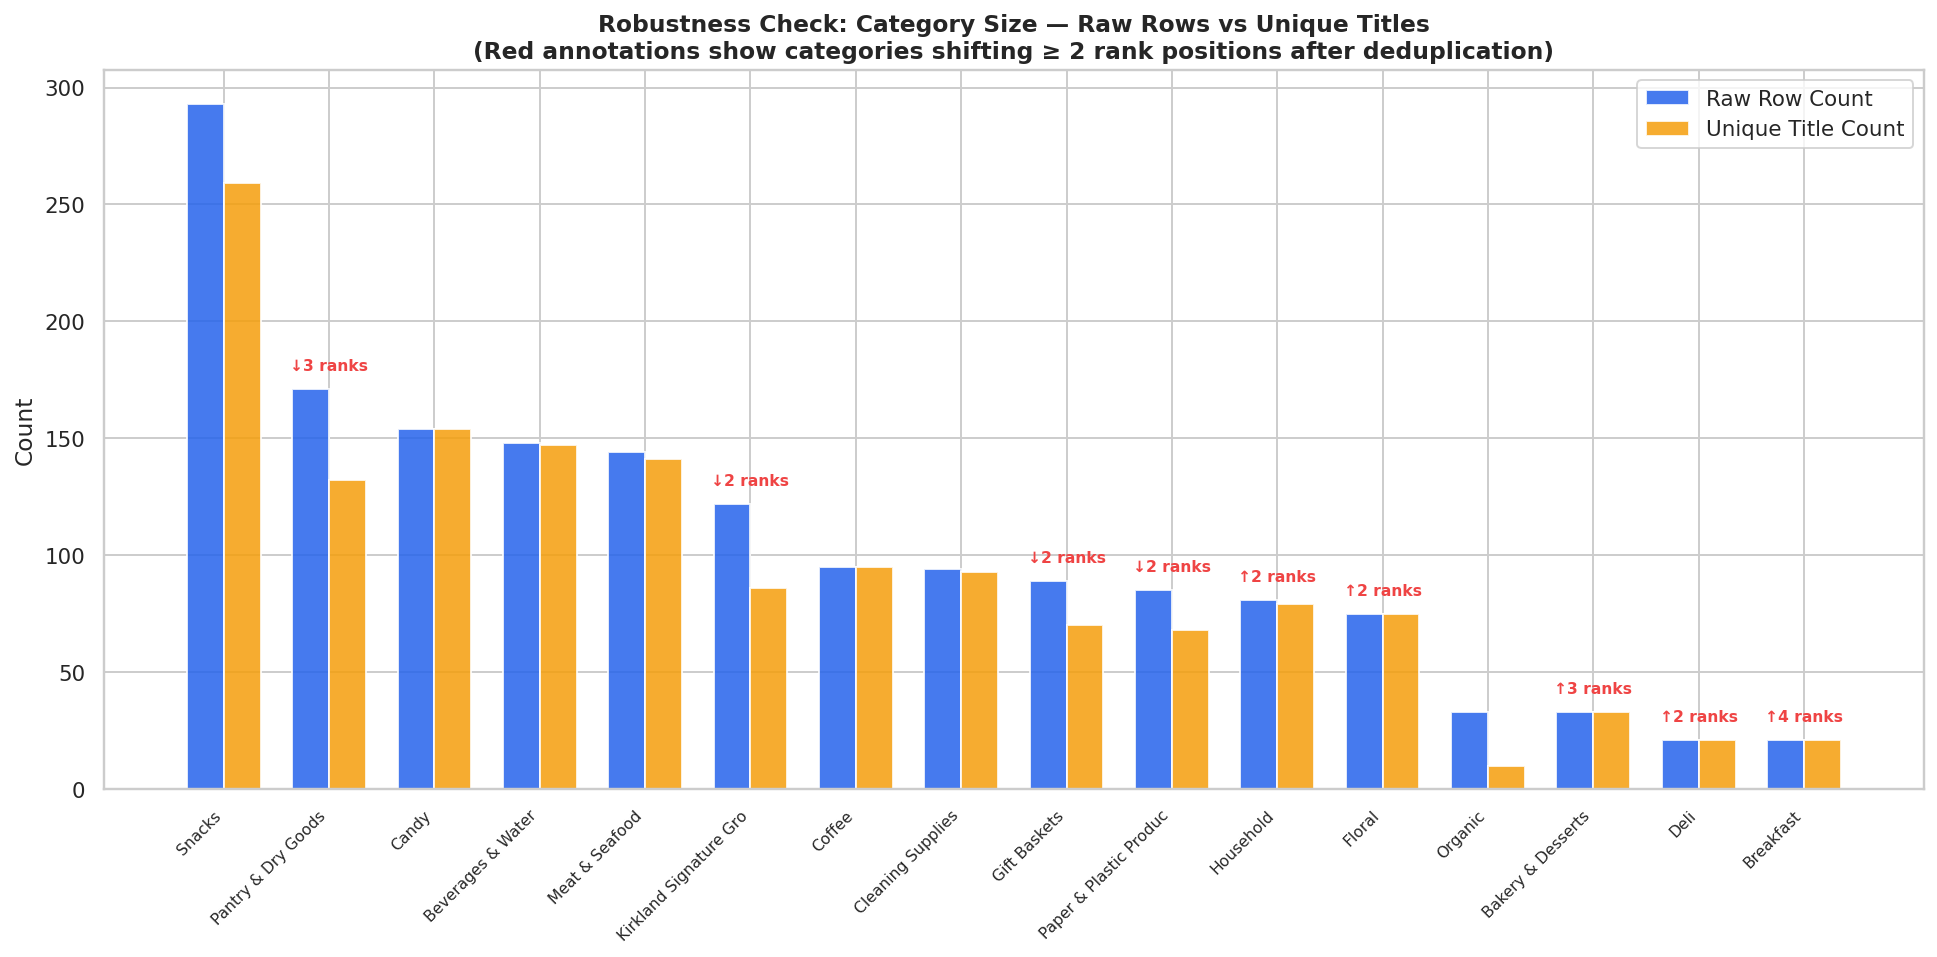

In [40]:
plot_merged = merged.sort_values('raw_rank').head(16).copy()
plot_merged['cat_short'] = plot_merged['category'].str[:22]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(plot_merged))
w = 0.35
bars1 = ax.bar(x - w/2, plot_merged['raw_count'], w, label='Raw Row Count',
               color=BLUE, edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + w/2, plot_merged['dedup_count'], w, label='Unique Title Count',
               color=AMBER, edgecolor='white', alpha=0.85)

# Mark rank shifts
for i, (_, row) in enumerate(plot_merged.iterrows()):
    shift = row['rank_change']
    if abs(shift) >= 2:
        direction = "↓" if shift < 0 else "↑"
        ax.annotate(f"{direction}{abs(shift)} ranks",
                    xy=(i, max(row['raw_count'], row['dedup_count']) + 8),
                    ha='center', fontsize=8, fontweight='bold', color=RED)

ax.set_xticks(x)
ax.set_xticklabels(plot_merged['cat_short'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Count')
ax.set_title('Robustness Check: Category Size — Raw Rows vs Unique Titles\n'
             '(Red annotations show categories shifting ≥ 2 rank positions after deduplication)',
             fontweight='bold', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('/home/claude/fig_13_rank_robustness.png', bbox_inches='tight')
plt.show()

print("Pantry & Dry Goods drops 3 ranks (2nd → 5th), Kirkland Signature drops 2 (6th → 8th),")
print("while Candy and Beverages rise. This confirms that cross-listing materially")
print("distorts category rankings.")

---
## 6 · Key Findings & Recommendations

### Summary of 4 Strongest Findings

Each finding is grounded in specific numbers and acknowledges limitations.

In [ ]:
print("=" * 70)
print("FINDING 1: THE CATALOG IS A MULTI-CATEGORY RETAIL TAXONOMY,")
print("           NOT A CLEAN PRODUCT TABLE")
print("=" * 70)
print(f"""
• {len(multi_cat_titles)} product titles ({len(multi_cat_titles)/df['Title'].nunique()*100:.0f}% of unique titles) 
  appear in 2+ categories. These {len(multi_cat_titles)} titles account for {df['is_crosslisted'].sum()} 
  of {len(df)} total rows; the other {len(single_cat_titles)} titles each appear once.
  Net extra rows from cross-listing: {len(df) - df['Title'].nunique()} (= {len(df)} rows − {df['Title'].nunique()} unique titles).
• The heaviest overlap is Meat & Seafood ↔ Seafood (47 shared titles) and 
  Cleaning Supplies ↔ Laundry (39 shared).
• "Kirkland Signature Grocery" is really a brand tag — 83% of its products 
  are cross-listed into functional categories.
• Implication: Raw category counts overstate assortment breadth. Any 
  category-level metric should be reported alongside unique-title counts 
  and cross-listing rates. The robustness chart (Section 5.6) confirms that
  Pantry & Dry Goods drops 3 rank positions and Kirkland drops 2 when
  cross-listed rows are collapsed.
""")

print("=" * 70)
print("FINDING 2: RATING COVERAGE IS THE DOMINANT DATA GAP,")
print("           AND IT VARIES WILDLY BY CATEGORY")
print("=" * 70)
print(f"""
• Only {rated['rating'].notna().sum()} of {len(df)} listings ({df['rating'].notna().mean()*100:.0f}%) have any rating.
• Coverage ranges from 0% (Household, 81 listings) to 100% (Poultry, 9 listings).
• Seven categories have < 25% coverage: Snacks, Candy, Beverages, Kirkland, 
  Paper Products, Breakfast, Household.
• This means category-level rating comparisons (e.g., "Kirkland is highest-rated") 
  are based on small, potentially non-representative samples.
• Priority action: High-price unrated products in Meat & Seafood ($200+ items 
  with no reviews) are the strongest candidates for review solicitation.
""")

print("=" * 70)
print("FINDING 3: KIRKLAND SIGNATURE SHOWS STRONG SIGNALS BUT")
print("           WITH IMPORTANT CAVEATS")
print("=" * 70)
print(f"""
• 159 unique Kirkland-branded titles across the catalog, priced lower (median $17 vs $29).
  (Note: the "Kirkland Signature Grocery" category contains 122 rows / 19 rated;
  the brand-level view captures an additional 37 titles listed only in functional
  categories like Snacks, Coffee, and Pantry.)
• Among the 27 unique rated Kirkland titles (17% title-level coverage):
  mean rating 4.60 (vs 4.33), median reviews 1,957 (vs 184). ~10× non-Kirkland engagement.
• BUT: 17% coverage means the rated subset likely skews toward the brand's
  most popular items. The magnitude of the advantage is uncertain.
""")

print("=" * 70)
print("FINDING 4: THE CATALOG MIXES DISTINCT PRODUCT WORLDS")
print("           THAT BEHAVE VERY DIFFERENTLY")
print("=" * 70)
print(f"""
• Gifting & Premium (Gift Baskets + Floral): median $60, 80% coverage, 
  median 553 reviews. Floral alone accounts for 5 of the top 10 
  most-reviewed products.
• Protein & Perishable (Meat/Seafood): median $200, 90% coverage, 
  but median only 104 reviews. High prices, low engagement.
• Food & Beverage (Snacks/Candy/Coffee/etc.): median $19, only 23% coverage, 
  median 266 reviews. Volume play with a visibility gap.
• Household & Cleaning: median $22, 22% coverage. Almost invisible 
  from a review perspective.
• These families respond to different strategies: gifting products need 
  merchandising prominence, protein needs review solicitation, 
  food/beverage needs rating coverage.
""")

print("\n" + "=" * 70)
print("RECOMMENDATIONS (derived from findings above)")
print("=" * 70)
print(f"""
1. RATING COVERAGE CAMPAIGN (from Finding 2):
   Prioritize review solicitation for high-price unrated products, especially 
   in Meat & Seafood ($200+ items) and Kirkland Signature. Even modest 
   coverage (going from 11% → 30%) would significantly improve the 
   reliability of category-level insights and customer confidence.

2. LEVERAGE KIRKLAND — CAUTIOUSLY (from Finding 3):
   The private-label signal is strong enough to justify prominent placement, 
   but monitor whether expanded rating coverage confirms or moderates the 
   4.60 average. The current evidence suggests Kirkland is a strong value 
   proposition (lower price, high ratings among reviewed products).

3. CLEAN THE TAXONOMY (from Finding 1):
   Assign each product a single primary category. The current cross-listing 
   creates confusion in any analytics pipeline. At minimum, separate 
   "Kirkland Signature" as a brand tag from functional product categories.

4. SEGMENT STRATEGY BY PRODUCT FAMILY (from Finding 4):
   Do not apply one-size-fits-all tactics across a catalog that spans 
   $5 kosher snacks and $2,000 caviar. Gifting products benefit from 
   seasonal merchandising; proteins from trust-building (reviews, photos); 
   staples from value messaging and pack-size optimization.
""")

print("=" * 70)
print("EDA COMPLETE")
print("=" * 70)

# Brand Analysis:

### 1. Finding the types of brands and matching each entry to its respective brand:

In [45]:
import pandas as pd
import re
from collections import Counter

# ----------------------------
# 1. LOAD DATA
# ----------------------------
df = pd.read_csv("GroceryDataset (1).csv")

# ----------------------------
# 2. CLEAN TITLES
# ----------------------------
df["title_clean"] = (
    df["Title"]
    .str.lower()
    .str.replace(r"[^a-z0-9\s]", "", regex=True)
    .str.strip()
)

# ----------------------------
# 3. EXTRACT N-GRAM CANDIDATES
# ----------------------------
def extract_candidates(title):
    words = title.split()
    candidates = []
    
    if len(words) >= 1:
        candidates.append(words[0])
    if len(words) >= 2:
        candidates.append(" ".join(words[:2]))
    if len(words) >= 3:
        candidates.append(" ".join(words[:3]))
    
    return candidates

all_candidates = []
for t in df["title_clean"]:
    all_candidates.extend(extract_candidates(t))

candidate_counts = Counter(all_candidates)

# ----------------------------
# 4. FILTER BAD CANDIDATES
# ----------------------------
STOPWORDS = {
    "the", "a", "an", "and", "or", "for"
}

BAD_PATTERNS = [
    "day", "pack", "count", "oz", "lb", "servings",
    "preorder", "variety", "bundle"
]

def is_valid_brand(candidate):
    words = candidate.split()
    
    # Remove stopwords
    if candidate in STOPWORDS:
        return False
    
    # Remove short junk
    if len(candidate) <= 2:
        return False
    
    # Remove numeric-heavy or product descriptors
    for bad in BAD_PATTERNS:
        if bad in candidate:
            return False
    
    return True

# Lower threshold to capture more brands
MIN_FREQ = 2

brand_candidates = {
    k for k, v in candidate_counts.items()
    if v >= MIN_FREQ and is_valid_brand(k)
}

# ----------------------------
# 5. ASSIGN BRAND (IMPROVED LOGIC)
# ----------------------------
def assign_brand(title):
    words = title.split()
    
    # PRIORITY: 2-word → 1-word → (optional 3-word last)
    
    # Try 2-word
    if len(words) >= 2:
        candidate = " ".join(words[:2])
        if candidate in brand_candidates:
            return candidate
    
    # Try 1-word
    if len(words) >= 1:
        candidate = words[0]
        if candidate in brand_candidates:
            return candidate
    
    # OPTIONAL: try 3-word (LOW PRIORITY)
    if len(words) >= 3:
        candidate = " ".join(words[:3])
        if candidate in brand_candidates:
            return candidate
    
    return "unknown"

df["brand"] = df["title_clean"].apply(assign_brand)


# ----------------------------
# 6. STRONG NORMALIZATION RULES
# ----------------------------
def normalize_brand(b):
    
    # --- Major brands ---
    if "kirkland" in b:
        return "kirkland signature"
    
    if "davids" in b:
        return "davids cookies"
    
    if "ferrara" in b:
        return "ferraras bakery"
    
    if "lacroix" in b or "la croix" in b:
        return "lacroix"
    
    if "pellegrino" in b:
        return "san pellegrino"
    
    if "red bull" in b:
        return "red bull"
    
    if "ziploc" in b:
        return "ziploc"
    
    if "hershey" in b:
        return "hersheys"
    
    if "jack links" in b:
        return "jack links"
    
    if "5hour" in b:
        return "5-hour energy"
    
    # --- Remove fake/event-based brands ---
    if "valentines" in b:
        return "unknown"
    
    # --- Clean trailing descriptors ---
    words = b.split()
    if len(words) > 2:
        return " ".join(words[:2])
    
    return b

df["brand"] = df["brand"].apply(normalize_brand)
# ----------------------------
# 7. OUTPUT
# ----------------------------
# ----------------------------
# FINAL BRAND CLEANUP (REPORT-READY)
# ----------------------------
def final_clean_brand(b):
    
    # --- Fix known full brands ---
    if "cake bake shop" in b or b == "the cake":
        return "the cake bake shop"
    
    if "unscented" in b:
        return "the unscented company"
    
    if "st michel" in b:
        return "st michel"
    
    if "nellies" in b:
        return "nellies"
    
    if "tsar nicoulai" in b:
        return "tsar nicoulai"
    
    if "plaza osetra" in b:
        return "plaza osetra"
    
    if "ruta maya" in b:
        return "ruta maya"
    
    if "made in nature" in b or b == "made in":
        return "made in nature"
    
    # --- Remove clearly non-brand phrases ---
    BAD_BRANDS = [
        "authentic wagyu",
        "the fruit",
        "valentines",
    ]
    
    for bad in BAD_BRANDS:
        if bad in b:
            return "unknown"
    
    return b

df["brand"] = df["brand"].apply(final_clean_brand)

# ----------------------------
# FINAL CHECK
# ----------------------------
print("Final top brands:")
print(df["brand"].value_counts().head(20))

Final top brands:
unknown                  347
kirkland signature       281
northwest fish            19
nellies                   18
tsar nicoulai             15
davids cookies            12
hersheys                  12
the unscented company     12
red bull                  11
chicago steak             11
jack links                11
ziploc                     9
plaza osetra               8
ferraras bakery            8
tide pods                  8
ruta maya                  7
marathon                   7
made in nature             7
nouvelle legende           7
peets coffee               7
Name: brand, dtype: int64


### 2. Extracting Rating & Review Count from string data:

In [49]:
import re

# Extract rating (e.g., 4.6)
df["rating_clean"] = df["Rating"].str.extract(r"Rated\s([\d\.]+)").astype(float)

# Extract review count (e.g., 2893)
df["review_count"] = df["Rating"].str.extract(r"based on (\d+)").astype(float)

df[["Rating", "rating_clean", "review_count"]].head()

,Rating,rating_clean,review_count
0,Rated 4.3 out of 5 stars based on 265 reviews.,4.3,265.0
1,Rated 5 out of 5 stars based on 1 reviews.,5.0,1.0
2,Rated 4.1 out of 5 stars based on 441 reviews.,4.1,441.0
3,Rated 4.7 out of 5 stars based on 9459 reviews.,4.7,9459.0
4,Rated 4.5 out of 5 stars based on 758 reviews.,4.5,758.0


### 3. Extracting pricing as numeric data from Price and Discount columns:

In [52]:
import numpy as np

def clean_price(price_str):
    if pd.isna(price_str):
        return np.nan
    
    # Extract all numbers from string
    nums = re.findall(r"\d+\.\d+", str(price_str))
    
    if len(nums) == 0:
        return np.nan
    
    # Convert to floats
    nums = [float(n) for n in nums]
    
    # Take average if multiple prices exist
    return sum(nums) / len(nums)

df["price_clean"] = df["Price"].apply(clean_price)
df["discount_clean"] = pd.to_numeric(df["Discount"], errors="coerce")

### 4. Finding the average price, average review and average product count:

In [53]:
brand_df = (
    df[df["brand"] != "unknown"]
    .groupby("brand")
    .agg(
        product_count=("Title", "count"),
        avg_rating=("rating_clean", "mean"),
        total_reviews=("review_count", "sum"),
        avg_price=("price_clean", "mean")
    )
    .reset_index()
)

# Filter small brands
brand_df = brand_df[brand_df["product_count"] >= 5]

# Drop missing values
brand_df = brand_df.dropna()

print(brand_df.head())

                brand  product_count  avg_rating  total_reviews   avg_price
0             100stem              5    4.280000         8357.0   67.990000
4              50stem              6    3.883333        24452.0   49.990000
36      boulder clean              5    4.300000          511.0   26.790000
58      chicago steak             11    4.560000         2417.0  240.899091
61  chocolate covered              5    4.000000           67.0   55.990000


In [62]:
brand_df.to_csv("brands.csv", index=False)

### 5. Clustering to find brand clusters according to the aggregated above metrics:

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ["total_reviews", "avg_rating", "avg_price"]

X = brand_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
brand_df["cluster"] = kmeans.fit_predict(X_scaled)

#### 5.1. Raw, Unnamed Clusters:

In [55]:
import plotly.express as px

fig = px.scatter(
    brand_df,
    x="total_reviews",
    y="avg_rating",
    size="product_count",
    color="cluster",
    hover_name="brand",
    title="Brand Clusters: Popularity vs Quality",
    size_max=60
)

fig.show()

#### 5.2. Observing cluster metrics and renaming clusters:

In [56]:
cluster_summary = brand_df.groupby("cluster")[["total_reviews", "avg_rating", "avg_price"]].mean()
print(cluster_summary)

         total_reviews  avg_rating   avg_price
cluster                                       
0          4433.909091    4.082576  118.563525
1          4390.222222    4.585498  158.695840
2         63714.000000    4.600000   20.677189


In [59]:
def name_cluster(c):
    if c == 2:
        return "Mass-Market Dominant"
    elif c == 1:
        return "Premium High-Quality"
    else:
        return "Mid-Tier / Lower Satisfaction"

brand_df["segment"] = brand_df["cluster"].apply(name_cluster)

In [60]:
fig = px.scatter(
    brand_df,
    x="total_reviews",
    y="avg_rating",
    size="product_count",
    color="segment",
    hover_name="brand",
    title="Brand Segmentation: Costco Market Positioning",
    size_max=60
)

fig.show()